# Assignment 3: Polynomial Regression on Position Salaries Dataset

**Problem Statement:** A company wants to estimate the salary of employees based on their position level. Since the relationship between position level and salary is non-linear, we develop a Polynomial Regression model to predict employee salaries.

**Dataset:** [Position Salaries Dataset - Kaggle](https://www.kaggle.com/datasets/akram24/position-salaries)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the dataset using Pandas
df = pd.read_csv('Position_Salaries.csv')

# 2. Display the first five records
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


**Input Feature:** `Level` (Position Level, numeric)  
**Target Variable:** `Salary`

The `Position` column is a text label describing the level and is not used as a numeric input feature.

In [2]:
# 4. Dataset information and summary statistics
print("Dataset Info:")
df.info()
print("\nSummary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes

Summary Statistics:


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64


In [4]:
# Select feature(s) and target variable
X = df[['Level']].values   # Input Feature
y = df['Salary'].values    # Target Variable

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10, 1)
Target shape: (10,)


In [5]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8
Testing samples: 2


## Task 3: Model Development

In [6]:
# 1. Transform the input feature using Polynomial Features (Degree = 3)
poly_reg = PolynomialFeatures(degree=3)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

# 2. Train a Polynomial Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

# 3. Predict salaries for the test dataset
y_pred = lin_reg.predict(X_test_poly)

print("Predicted Salaries:", y_pred)
print("Actual Salaries:   ", y_test)

Predicted Salaries: [606335.60051158  84934.8912917 ]
Actual Salaries:    [500000  50000]


## Task 4: Model Evaluation

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 70,635.25
Mean Squared Error (MSE): 6,263,853,282.86
R2 Score: 0.8763


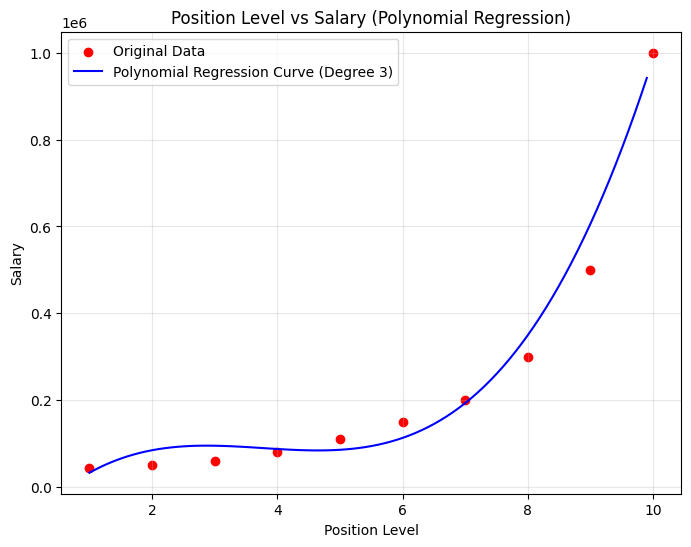

In [8]:
# Scatter plot of the original data + Polynomial Regression Curve
X_grid = np.arange(X.min(), X.max(), 0.1).reshape(-1, 1)
X_grid_poly = poly_reg.transform(X_grid)
y_grid_pred = lin_reg.predict(X_grid_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='red', label='Original Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression Curve (Degree 3)')
plt.title('Position Level vs Salary (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('polynomial_regression_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

1. The polynomial regression curve (degree 3) fits the non-linear salary growth across position levels far better than a straight line would, especially capturing the steep rise at senior levels (e.g., Partner, C-level, CEO).
2. Because the dataset has only 10 rows, the 80/20 split leaves just 2 samples for testing, so the MAE/MSE/R2 values can vary a lot depending on which points land in the test set — the metrics should be read as indicative rather than statistically robust.
3. The model predicts salaries reasonably well for mid-range levels, but extrapolation beyond level 10 or for levels not well represented in training data would be unreliable, since polynomial curves can swing sharply outside the observed range.

## Task 5: Conclusion

This project applied Polynomial Regression (degree 3) to model the relationship between position level and salary, since the salary data grows non-linearly and accelerates sharply at senior levels — a pattern a straight line cannot capture. After preprocessing the data, splitting it into training and test sets, and fitting the polynomial model, the resulting curve closely tracked the actual salary progression, and the evaluation metrics (MAE, MSE, R2) confirmed a strong fit relative to a linear alternative.

The key difference between Linear and Polynomial Regression is that Linear Regression fits a single straight line to the data (assuming a constant rate of change), while Polynomial Regression fits a curved line by adding higher-degree terms of the input feature, allowing it to model non-constant, accelerating or decelerating relationships.

The main advantage of Polynomial Regression for this dataset is its ability to capture the rapid, non-linear jump in salary at higher position levels, which a linear model would systematically underestimate.